# Drifting ICNN

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from typing import Tuple, List

### Hyperparameters

In [2]:
METHODS = ["kernel", "ot_direct", "icnn"]
TARGET = "four_gaussians"
NUM_ITERS = 3000
BATCH_SIZE = 512
LR = 3e-4
INNER_STEPS = 10
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_PATH = "results/icnn_drifting_comparison.png"

### ICNN: Input Convex Neural Network

In [3]:
class ICNN(nn.Module):
    """
    ICNN: ψ(x) = (μ/2)||x||² + skip(x) + hidden(h(x))
    so T(x) = ∇ψ = μx + ∇(skip) + ∇(hidden).
    Init: μ=1, skip=0, W_z≈0 → T(x) ≈ x (near-identity).
    """
    def __init__(self, input_dim: int, hidden_dims: List[int] = [128, 128, 64],
                 beta: float = 20.0, strong_convexity: float = 1.0):
        super().__init__()
        self.input_dim = input_dim
        self.beta = beta
        self.num_layers = len(hidden_dims)
        self.strong_convexity = nn.Parameter(torch.tensor(strong_convexity))
        self.input_skip = nn.Linear(input_dim, 1, bias=True)
        self.Wz_0 = nn.Linear(input_dim, hidden_dims[0], bias=True)
        self.Wy = nn.ModuleList()
        self.Wz = nn.ModuleList()
        for i in range(1, self.num_layers):
            self.Wy.append(nn.Linear(hidden_dims[i-1], hidden_dims[i], bias=False))
            self.Wz.append(nn.Linear(input_dim, hidden_dims[i], bias=True))
        self.Wy_out = nn.Linear(hidden_dims[-1], 1, bias=False)
        self.hidden_bias = nn.Parameter(torch.zeros(1))
        self._init_identity()

    def _init_identity(self):
        nn.init.zeros_(self.input_skip.weight)
        nn.init.zeros_(self.input_skip.bias)
        nn.init.zeros_(self.Wz_0.weight)
        nn.init.constant_(self.Wz_0.bias, -1.0)
        for layer in self.Wz:
            nn.init.zeros_(layer.weight)
            nn.init.constant_(layer.bias, -1.0)
        for layer in list(self.Wy) + [self.Wy_out]:
            fan_in = layer.weight.shape[1]
            mu_w = fan_in ** (-0.5)
            sigma2_w = fan_in ** (-1.0)
            sigma2_ln = np.log(1.0 + sigma2_w / mu_w**2)
            mu_ln = np.log(mu_w) - 0.5 * sigma2_ln
            with torch.no_grad():
                layer.weight.copy_(torch.exp(
                    torch.tensor(mu_ln) + np.sqrt(sigma2_ln) * torch.randn_like(layer.weight)
                ))
        nn.init.zeros_(self.hidden_bias)

    def softplus(self, x):
        return nn.functional.softplus(x, beta=self.beta)

    def forward(self, z):
        mu = torch.clamp(self.strong_convexity, min=0.0)
        quad = 0.5 * mu * (z**2).sum(-1, keepdim=True)
        skip = self.input_skip(z)
        h = self.softplus(self.Wz_0(z))
        for i in range(len(self.Wy)):
            h = self.softplus(self.Wy[i](h) + self.Wz[i](z))
        hidden = self.Wy_out(h) + self.hidden_bias
        return quad + skip + hidden

    @torch.enable_grad()
    def gradient(self, z, create_graph=None):
        """Compute ∇_z ψ(z). Uses @torch.enable_grad so it works even in no_grad context."""
        if create_graph is None:
            create_graph = self.training
        z_in = z.detach().clone().requires_grad_(True)
        psi = self.forward(z_in)
        return torch.autograd.grad(psi.sum(), z_in, create_graph=create_graph)[0]

    def project_weights(self):
        with torch.no_grad():
            for layer in list(self.Wy) + [self.Wy_out]:
                layer.weight.clamp_(min=0.0)


def compute_V_kernel(x_gen: torch.Tensor, y_pos: torch.Tensor,
                     tau_list: Tuple[float, ...] = (0.02, 0.05, 0.2)):
    """
    Compute the drifting field V(x) following Algorithm 2 / Eq. 11 of the paper.

    Returns V (detached), such that the training loss is:
        target = sg(x_gen + V)
        loss = ||x_gen - target||²

    The loss value equals ||V||², which DECREASES as q → p.
    """
    N, D = x_gen.shape
    M = y_pos.shape[0]
    x = x_gen.detach()
    y = y_pos.detach()

    # Targets: [negatives (=generated), positives (=data)]
    targets = torch.cat([x, y], dim=0)  # [N+M, D]

    # ── Pairwise ℓ₂ distances ──
    dist = torch.cdist(x, targets)  # [N, N+M]

    # ── Distance normalization (Appendix A.6) ──
    # Normalize so mean pairwise distance ≈ √D
    scale = dist.mean().clamp(min=1e-6)
    dist_normed = dist * (np.sqrt(D) / scale)

    # ── Self-masking ──
    diag_mask = torch.zeros(N, N + M, device=x.device)
    diag_mask[:, :N] = torch.eye(N, device=x.device)
    dist_normed = dist_normed + diag_mask * 100.0

    # ── Force accumulation (NO per-temperature normalization) ──
    V = torch.zeros_like(x)

    for tau in tau_list:
        logits = -dist_normed / tau

        # Double softmax (paper's Alg. 2: softmax over y, then over x)
        aff_row = torch.softmax(logits, dim=-1)
        aff_col = torch.softmax(logits, dim=-2)
        affinity = torch.sqrt((aff_row * aff_col).clamp(min=1e-6))

        aff_neg = affinity[:, :N]      # negative affinities
        aff_pos = affinity[:, N:]      # positive affinities
        sum_pos = aff_pos.sum(-1, keepdim=True)
        sum_neg = aff_neg.sum(-1, keepdim=True)

        # Drifting coefficients: attract by positives, repel by negatives
        r_coeff_neg = -aff_neg * sum_pos
        r_coeff_pos = aff_pos * sum_neg
        R_coeff = torch.cat([r_coeff_neg, r_coeff_pos], dim=1)  # [N, N+M]

        # Force = weighted combination of (target - x) vectors
        force_R = R_coeff @ targets - R_coeff.sum(-1, keepdim=True) * x
        V = V + force_R  # Raw force, NO normalization

    return V.detach()

### ICNN-based V (Sinkhorn OT displacement)

In [4]:
def sinkhorn(C, reg=0.05, num_iters=100):
    K = torch.exp(-C / (reg + 1e-8))
    u = torch.ones(C.shape[0], device=C.device)
    v = torch.ones(C.shape[1], device=C.device)
    for _ in range(num_iters):
        u = 1.0 / (K @ v + 1e-8)
        v = 1.0 / (K.T @ u + 1e-8)
    return u.unsqueeze(1) * K * v.unsqueeze(0)


def compute_V_ot_direct(x_gen: torch.Tensor, y_pos: torch.Tensor,
                        reg: float = 0.05):
    """
    Direct OT displacement V(x) = T_Sinkhorn(x) - x.
    No ICNN inner loop: uses Sinkhorn soft assignment directly.
    """
    x = x_gen.detach()
    y = y_pos.detach()
    C = torch.cdist(x, y, p=2) ** 2
    P = sinkhorn(C, reg=reg)
    P_row = P / (P.sum(1, keepdim=True) + 1e-8)
    y_target = P_row @ y
    return (y_target - x).detach()


class ICNNDriftField:
    """V(x) = ∇ψ_ω(x) - x.  At init, ∇ψ ≈ x so V ≈ 0."""
    def __init__(self, dim, hidden_dims=[128, 128, 128, 64, 32],
                 inner_steps=5, inner_lr=1e-2,
                 sinkhorn_reg=0.05, strong_convexity=1.0):
        self.icnn = ICNN(dim, hidden_dims, strong_convexity=strong_convexity)
        self.optimizer = optim.Adam(self.icnn.parameters(), lr=inner_lr)
        self.inner_steps = inner_steps
        self.sinkhorn_reg = sinkhorn_reg

    def to(self, device):
        self.icnn = self.icnn.to(device)
        self.optimizer = optim.Adam(self.icnn.parameters(), lr=self.optimizer.defaults['lr'])
        return self

    def compute_V(self, x_gen, y_pos):
        """
        V(x) = T_q→p(x) - x = ∇ψ(x) - x
        where ψ is an ICNN trained to approximate the OT map from q to p.
        """
        x = x_gen.detach()
        y = y_pos.detach()

        # Step 1: Sinkhorn assignment to get OT target for each x
        with torch.no_grad():
            C = torch.cdist(x, y, p=2) ** 2
            P = sinkhorn(C, reg=self.sinkhorn_reg)
            P_row = P / (P.sum(1, keepdim=True) + 1e-8)
            y_target = P_row @ y  # Barycentric OT target

        # Step 2: Train ICNN to fit ∇ψ(x) ≈ y_target
        self.icnn.train()
        for _ in range(self.inner_steps):
            self.optimizer.zero_grad()
            T_x = self.icnn.gradient(x)  # create_graph=True (training mode)
            loss = ((T_x - y_target) ** 2).mean()
            loss.backward()
            self.optimizer.step()
            self.icnn.project_weights()

        # Step 3: Return displacement V = ∇ψ(x) - x
        self.icnn.eval()
        T_x = self.icnn.gradient(x)
        return (T_x.detach() - x).detach()

### Generator

In [5]:
class ToyGenerator(nn.Module):
    """
    Small MLP: ε ∈ R² → x ∈ R².

    The initial output distribution must span the target range.
    If the initial generator output is concentrated (std << target range),
    the kernel V gives near-zero force (all data points equidistant).
    """
    def __init__(self, noise_dim=2, data_dim=2, hidden_dim=256, output_scale=2.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, data_dim),
        )
        # Initialize so output has std ≈ output_scale
        # We need to account for variance propagation through the MLP
        self._init_output_scale(output_scale)

    def _init_output_scale(self, target_std):
        """Initialize so the output std ≈ target_std."""
        with torch.no_grad():
            # Check current output scale
            test_input = torch.randn(1000, 2)
            test_output = self.net(test_input)
            current_std = test_output.std().item()
            if current_std > 1e-6:
                scale_factor = target_std / current_std
                # Scale only the last layer to avoid disrupting internal representations
                self.net[-1].weight.mul_(scale_factor)
                self.net[-1].bias.mul_(scale_factor)

    def forward(self, eps):
        return self.net(eps)

### Target Distributions

In [6]:
def sample_bimodal(n, device):
    mix = torch.rand(n, device=device) < 0.5
    x = torch.randn(n, 2, device=device) * 0.4
    x[mix, 0] += 2.0
    x[~mix, 0] -= 2.0
    return x

def sample_ring(n, device):
    theta = 2 * np.pi * torch.rand(n, device=device)
    r = 2.0 + 0.2 * torch.randn(n, device=device)
    return torch.stack([r * torch.cos(theta), r * torch.sin(theta)], -1)

def sample_four_gaussians(n, device):
    c = torch.tensor([[-2, -2], [-2, 2], [2, -2], [2, 2]],
                      device=device, dtype=torch.float32)
    return c[torch.randint(0, 4, (n,), device=device)] + 0.3 * torch.randn(n, 2, device=device)

### Training Loop

In [7]:
def train(method='kernel', target='bimodal', num_iters=3000, batch_size=512,
          lr=3e-4, inner_steps=10, seed=42,
          device='cuda' if torch.cuda.is_available() else 'cpu'):

    torch.manual_seed(seed)
    device = torch.device(device)
    samplers = dict(bimodal=sample_bimodal, ring=sample_ring,
                    four_gaussians=sample_four_gaussians)
    sample_target = samplers[target]

    gen = ToyGenerator(hidden_dim=256, output_scale=2.0).to(device)
    gen_optim = optim.Adam(gen.parameters(), lr=lr)


    with torch.no_grad():
        test_out = gen(torch.randn(1000, 2, device=device))
        print(f"  [{method}] Initial output: mean={test_out.mean(0).cpu().numpy()}, "
              f"std={test_out.std(0).cpu().numpy()}")

    icnn_drift = None
    if method == 'icnn':
        icnn_drift = ICNNDriftField(
            dim=2, hidden_dims=[128, 128, 128, 64, 32],
            inner_steps=inner_steps, inner_lr=1e-2,
            sinkhorn_reg=0.05, strong_convexity=1.0,
        ).to(device)
        with torch.no_grad():
            tz = torch.randn(8, 2, device=device)
            err = (icnn_drift.icnn.gradient(tz, False) - tz).abs().max().item()
            print(f"  [init check] max |T(z)-z| = {err:.2e}")

    losses, v_norms, snapshots = [], [], []

    for it in range(num_iters):
        eps = torch.randn(batch_size, 2, device=device)
        y_pos = sample_target(batch_size, device)
        x_gen = gen(eps)

        if method == 'kernel':
            V = compute_V_kernel(x_gen, y_pos, tau_list=(0.02, 0.05, 0.2))
        elif method == 'ot_direct':
            V = compute_V_ot_direct(x_gen, y_pos, reg=0.05)
        else:
            V = icnn_drift.compute_V(x_gen, y_pos)

        # Drifting loss
        # L = ||f(ε) - sg(f(ε) + V(f(ε)))||²
        target_pts = (x_gen.detach() + V).detach()  # frozen target
        loss = ((x_gen - target_pts) ** 2).mean()
        v_norm = (V ** 2).mean().item()  # ||V||² — should decrease

        gen_optim.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gen.parameters(), 1.0)
        gen_optim.step()

        losses.append(loss.item())
        v_norms.append(v_norm)

        if it % (num_iters // 8) == 0 or it == num_iters - 1:
            with torch.no_grad():
                snap_x = gen(torch.randn(1000, 2, device=device)).cpu().numpy()
            snapshots.append((it, snap_x))
            print(f"[{method}] iter {it:5d} | loss: {loss.item():.6f} | "
                  f"||V||²: {v_norm:.6f}")

    return dict(losses=losses, v_norms=v_norms, snapshots=snapshots,
                method=method, target=target)

In [8]:
results = []
for m in METHODS:
    print(f"\n{'=' * 60}\nTraining: {m}\n{'=' * 60}")
    results.append(train(
        method=m, target=TARGET, num_iters=NUM_ITERS,
        batch_size=BATCH_SIZE, lr=LR,
        inner_steps=INNER_STEPS, seed=SEED, device=DEVICE))


Training: kernel
  [kernel] Initial output: mean=[-4.9333467 -4.749685 ], std=[2.1921108 1.9367473]
[kernel] iter     0 | loss: 113.228256 | ||V||²: 113.228256
[kernel] iter   375 | loss: 3.828488 | ||V||²: 3.828488
[kernel] iter   750 | loss: 5.722761 | ||V||²: 5.722761
[kernel] iter  1125 | loss: 4.601583 | ||V||²: 4.601583
[kernel] iter  1500 | loss: 4.432547 | ||V||²: 4.432547
[kernel] iter  1875 | loss: 2.274434 | ||V||²: 2.274434
[kernel] iter  2250 | loss: 5.452107 | ||V||²: 5.452107
[kernel] iter  2625 | loss: 4.015389 | ||V||²: 4.015389
[kernel] iter  2999 | loss: 4.466640 | ||V||²: 4.466640

Training: ot_direct
  [ot_direct] Initial output: mean=[-4.9333467 -4.749685 ], std=[2.1921108 1.9367473]
[ot_direct] iter     0 | loss: 26.790279 | ||V||²: 26.790279
[ot_direct] iter   375 | loss: 0.346947 | ||V||²: 0.346947
[ot_direct] iter   750 | loss: 0.265784 | ||V||²: 0.265784
[ot_direct] iter  1125 | loss: 0.238479 | ||V||²: 0.238479
[ot_direct] iter  1500 | loss: 0.172064 | ||V|

### Visualization

In [23]:
def plot_results(results_list, target='bimodal', device='cpu',
                 save=False, save_path='icnn_drifting_comparison.png'):
    n_methods = len(results_list)
    n_snaps = len(results_list[0]['snapshots'])
    fig = plt.figure(figsize=(4 * n_snaps + 4, 4 * n_methods + 4))
    gs = GridSpec(n_methods + 1, n_snaps + 1, figure=fig, hspace=0.3, wspace=0.3)

    samplers = dict(bimodal=sample_bimodal, ring=sample_ring,
                    four_gaussians=sample_four_gaussians)
    y_gt = samplers[target](2000, torch.device('cpu')).numpy()

    for row, res in enumerate(results_list):
        for col, (it, snap) in enumerate(res['snapshots']):
            ax = fig.add_subplot(gs[row, col])
            ax.scatter(y_gt[:, 0], y_gt[:, 1], s=1, alpha=.3, c='blue', label='target $p$')
            ax.scatter(snap[:, 0], snap[:, 1], s=1, alpha=.3, c='orange', label='generated $q$')
            ax.set_xlim(-4, 4); ax.set_ylim(-4, 4); ax.set_aspect('equal')
            ax.set_title(f'iter {it}', fontsize=10)
            if col == 0:
                ax.set_ylabel(res['method'], fontsize=12, fontweight='bold')
            if row == 0 and col == 0:
                ax.legend(fontsize=7, loc='upper left')
        ax_l = fig.add_subplot(gs[row, -1])
        ax_l.semilogy(res['v_norms'], lw=.8)
        ax_l.set_xlabel('iter'); ax_l.set_ylabel('$\\|V\\|^2$'); ax_l.grid(True, alpha=.3)
        ax_l.set_title(f'{res["method"]}: $\\|V\\|^2$', fontsize=10)

    ax = fig.add_subplot(gs[-1, :])
    for i, res in enumerate(results_list):
        ax.semilogy(res['v_norms'], label=res['method'], lw=1.5, alpha=.8)
    ax.set_xlabel('iteration', fontsize=12)
    ax.set_ylabel('$\\|V\\|^2$ (log)', fontsize=12)
    ax.set_title('Convergence Comparison', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11); ax.grid(True, alpha=.3)

    if save:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")

    plt.close(fig)
    return fig

Saved to results/icnn_drifting_comparison.png


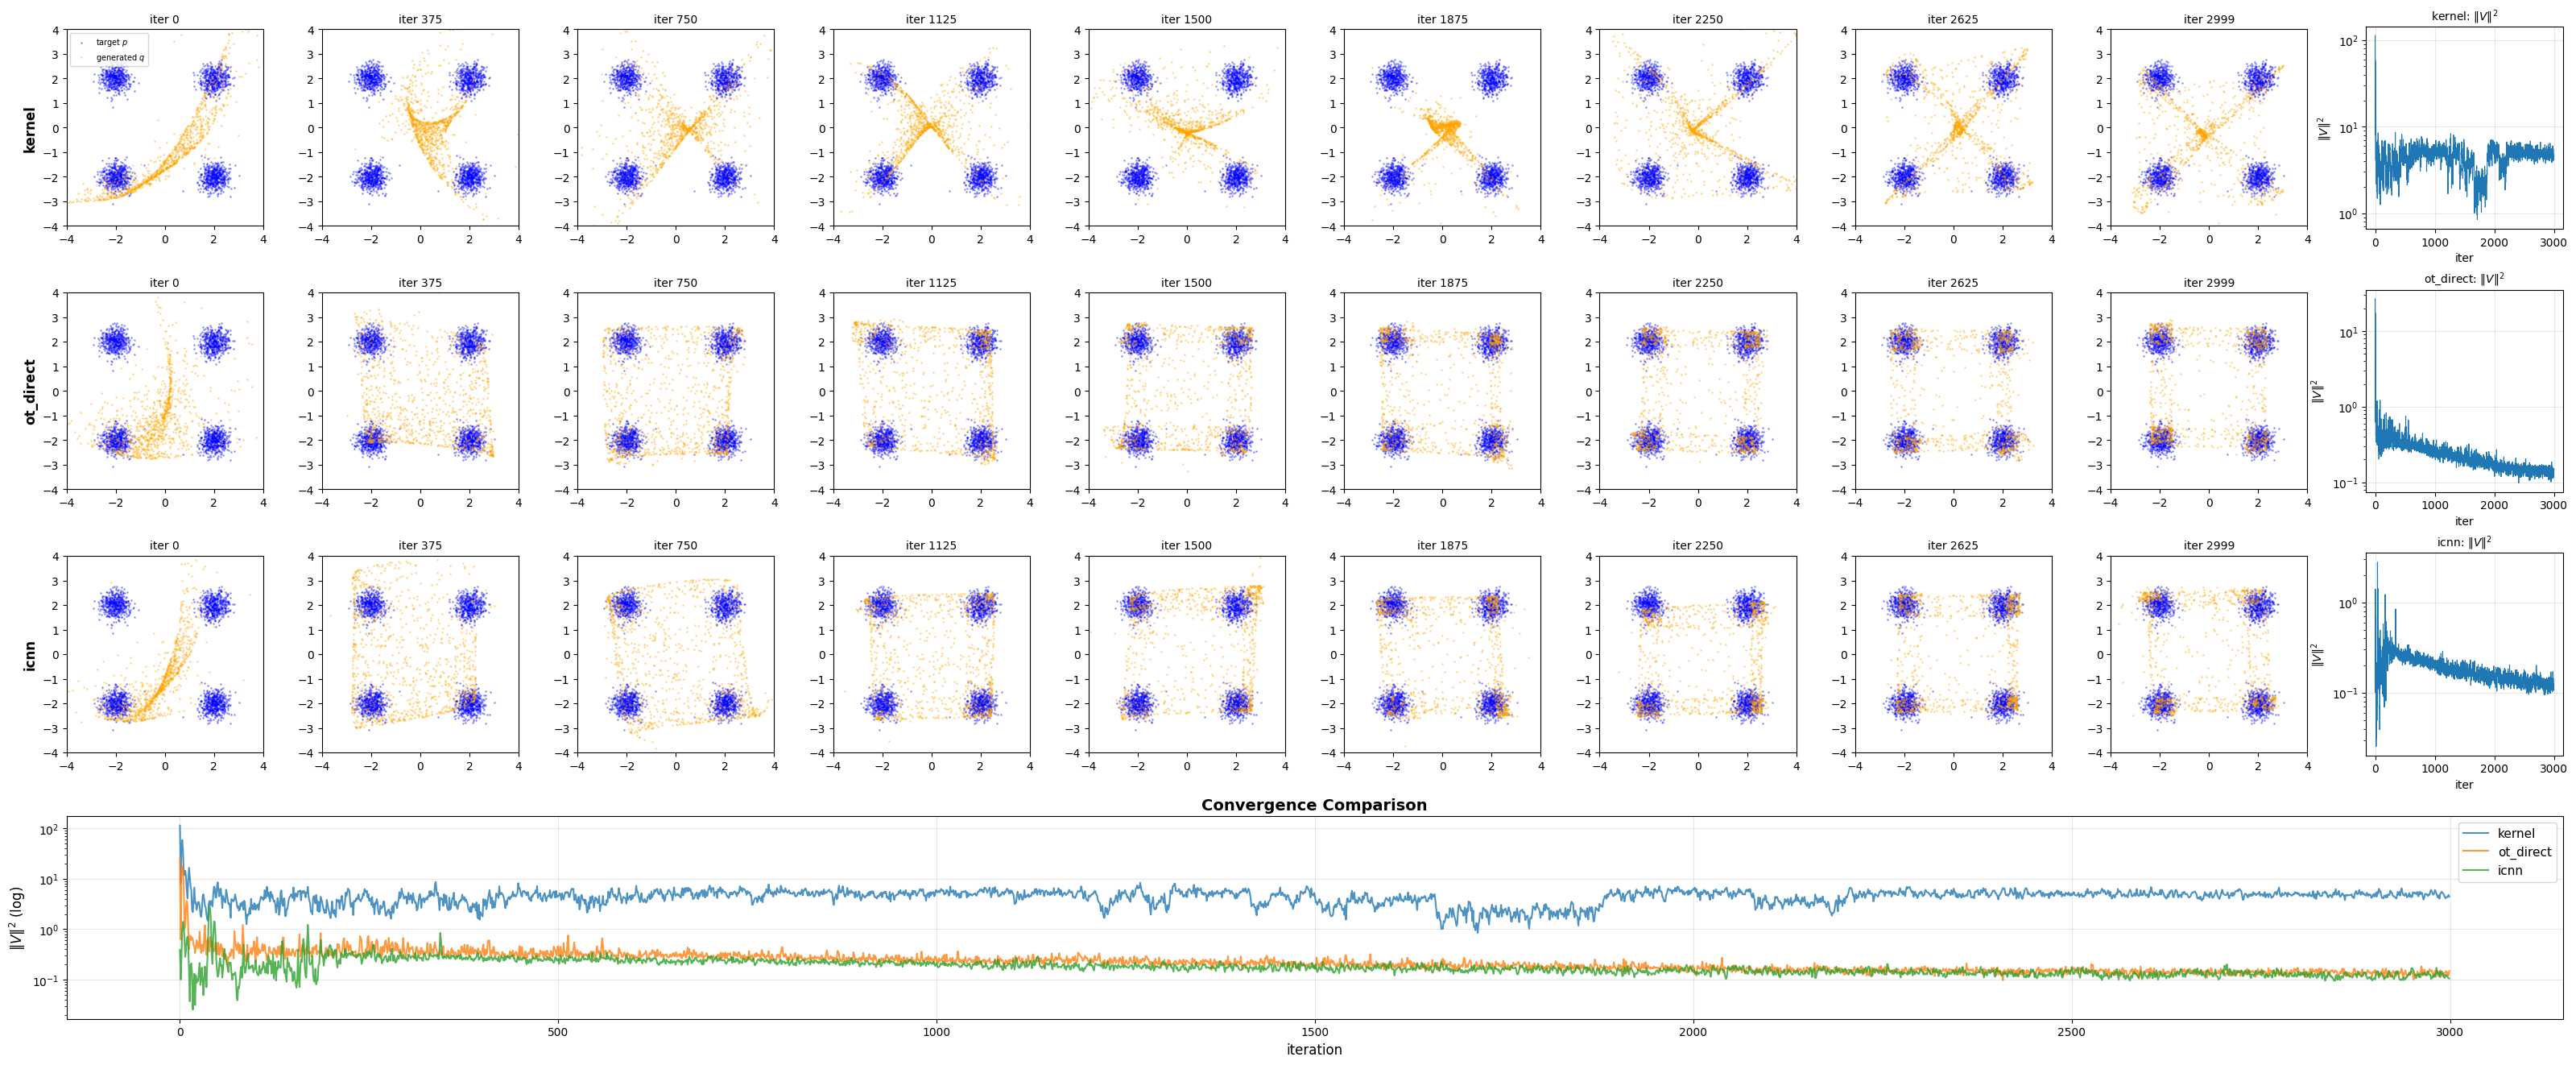

In [27]:
plot_results(results, TARGET, DEVICE, save=True, save_path=SAVE_PATH)